# 10 — ML Meta-Label Dataset

Bu aşamada Robot stratejisini değiştirmiyoruz. Makine öğrenmesinin görevi:

> Robotun ürettiği bir AL sinyalinin alınmaya değer olup olmadığını tahmin etmek.

Her satır bir Robot giriş olayıdır. Etiket, final stratejinin aynı çıkış
kuralları ve maliyetleriyle elde edilen net işlem sonucundan oluşturulur.

Önemli kurallar:

- Özellikler yalnızca sinyal günü ve geçmiş verileri kullanır.
- Giriş bir sonraki işlem günü açılışındadır.
- Aynı hissede bir işlem açıkken yeni örnek üretilmez.
- Portföy limiti uygulanmaz; amaç bütün birincil sinyal olaylarını öğrenmektir.
- `2025+` dönemi daha önce görüldüğü için gerçek anlamda dokunulmamış test
  değildir. Gerçek yeni out-of-sample doğrulama paper trading olacaktır.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.features import add_indicators
from src.signals import (
    build_market_regime,
    add_robot_scores,
)
from src.presets import (
    FINAL_STRATEGY_CONFIG,
    FINAL_PORTFOLIO_CONFIG,
)
from src.ml_dataset import (
    BASE_FEATURE_COLUMNS,
    TARGET_COLUMNS,
    add_meta_features,
    build_meta_label_dataset,
    leakage_audit,
    save_feature_manifest,
)


## 1. Temiz verileri yükle


In [2]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

print("Hisse verisi:", stock_prices.shape)
print("Endeks verisi:", market_prices.shape)
print(
    "Tarih aralığı:",
    stock_prices["Date"].min(),
    "→",
    stock_prices["Date"].max(),
)


Hisse verisi: (172321, 30)
Endeks verisi: (2131, 30)
Tarih aralığı: 2018-01-02 00:00:00 → 2026-07-24 00:00:00


## 2. Final Robot skorlarını ve ML özelliklerini üret


In [3]:
stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(market_features)

scored_prices = add_robot_scores(
    stock_features=stock_features,
    market_regime=market_regime,
    config=FINAL_STRATEGY_CONFIG,
    include_reasons=True,
)

featured_prices = add_meta_features(
    scored_prices=scored_prices,
    market_features=market_features,
)

print("Özellikli satır:", len(featured_prices))
print("Özellik sayısı:", len(BASE_FEATURE_COLUMNS))
print("AL sinyali satırı:", featured_prices["Signal"].eq("AL").sum())


Özellikli satır: 152459
Özellik sayısı: 31
AL sinyali satırı: 26793


## 3. Stratejiyle uyumlu olay etiketlerini oluştur


In [4]:
ml_dataset = build_meta_label_dataset(
    featured_prices=featured_prices,
    market_features=market_features,
    strategy_config=FINAL_STRATEGY_CONFIG,
    portfolio_config=FINAL_PORTFOLIO_CONFIG,
    feature_columns=BASE_FEATURE_COLUMNS,
)

print("Toplam olay:", len(ml_dataset))
print("Hisse sayısı:", ml_dataset["Ticker"].nunique())
print(
    "Sinyal tarih aralığı:",
    ml_dataset["Signal_Date"].min(),
    "→",
    ml_dataset["Signal_Date"].max(),
)

display(ml_dataset.head())


Toplam olay: 3902
Hisse sayısı: 98
Sinyal tarih aralığı: 2019-01-18 00:00:00 → 2026-07-23 00:00:00


,Ticker,Signal_Date,Entry_Date,Exit_Date,Signal_Close,Entry_Open_Raw,Entry_Price,Exit_Price,Period,Meta_Label,...,MARKET_RET_20,MARKET_RET_63,MARKET_VOLATILITY_20,SCORE_RANK_PCT,ADX_RANK_PCT,RET_63_RANK_PCT,RET_126_RANK_PCT,VOLUME_RATIO_RANK_PCT,Month,DayOfWeek
0,ANSGR.IS,2019-01-18,2019-01-21,2019-02-04,0.805893,0.805893,0.807505,0.791309,Development,0,...,0.063771,0.010271,0.192198,0.838235,0.338235,0.397059,0.632353,0.926471,1.0,4.0
1,ARCLK.IS,2019-01-18,2019-01-21,2019-03-14,15.901350,15.972141,16.004085,16.885131,Development,1,...,0.063771,0.010271,0.192198,0.919118,0.823529,0.941176,1.000000,0.647059,1.0,4.0
2,BERA.IS,2019-01-18,2019-01-21,2019-01-23,1.108703,1.118602,1.120839,1.027457,Development,0,...,0.063771,0.010271,0.192198,0.919118,0.882353,0.955882,0.779412,0.985294,1.0,4.0
3,BIMAS.IS,2019-01-18,2019-01-21,2019-01-22,18.233917,18.233919,18.270387,17.624269,Development,0,...,0.063771,0.010271,0.192198,0.992647,0.720588,0.882353,0.970588,0.661765,1.0,4.0
4,CCOLA.IS,2019-01-18,2019-01-21,2019-01-29,2.916347,2.919803,2.925642,2.793308,Development,0,...,0.063771,0.010271,0.192198,0.838235,0.235294,0.779412,0.750000,0.632353,1.0,4.0


## 4. Sansürlü ve aykırı örnekleri ayır

Verinin sonuna kadar kapanmamış işlemler `Is_Censored=True` olur. Bunlar
gelecekteki sonucu bilinmediği için model eğitiminde kullanılmamalıdır.


In [5]:
training_dataset = (
    ml_dataset.loc[
        ~ml_dataset["Is_Censored"]
        & ~ml_dataset["Is_Outlier"]
    ]
    .copy()
    .reset_index(drop=True)
)

excluded_summary = pd.DataFrame(
    [
        {
            "Total_Events": len(ml_dataset),
            "Censored_Events": int(
                ml_dataset["Is_Censored"].sum()
            ),
            "Outlier_Events": int(
                ml_dataset["Is_Outlier"].sum()
            ),
            "Training_Eligible_Events": len(
                training_dataset
            ),
        }
    ]
)

display(excluded_summary)


,Total_Events,Censored_Events,Outlier_Events,Training_Eligible_Events
0,3902,23,0,3879


## 5. Veri sızıntısı ve yapısal kontroller


In [6]:
leakage_report = leakage_audit(
    training_dataset
)

display(leakage_report)

if not leakage_report["Passed"].all():
    raise RuntimeError(
        "Leakage audit başarısız. Model aşamasına geçme."
    )


,Check,Passed,Details
0,Signal before entry,True,Her giriş sinyal gününden sonra olmalı.
1,Entry not after exit,True,Giriş tarihi çıkış tarihinden sonra olamaz.
2,Unique ticker-signal events,True,Ticker ve sinyal tarihi benzersiz olmalı.
3,No same-ticker overlapping events,True,Çakışan olay sayısı: 0
4,Binary primary label,True,Meta_Label yalnızca 0/1 olmalı.
5,No missing base features,True,Model özelliklerinde eksik değer olmamalı.


## 6. Dönem ve sınıf dağılımı


In [7]:
split_summary = (
    training_dataset.groupby("Period")
    .agg(
        Event_Count=("Meta_Label", "size"),
        Positive_Count=("Meta_Label", "sum"),
        Positive_Rate=("Meta_Label", "mean"),
        Average_Return_=("Net_Return_%", "mean"),
        Median_Return_=("Net_Return_%", "median"),
        Average_R_Multiple=("R_Multiple", "mean"),
        Average_Holding_Bars=("Holding_Bars", "mean"),
    )
    .reset_index()
)

split_summary["Positive_Rate_%"] = (
    split_summary["Positive_Rate"] * 100
)

display(split_summary)


,Period,Event_Count,Positive_Count,Positive_Rate,Average_Return_,Median_Return_,Average_R_Multiple,Average_Holding_Bars,Positive_Rate_%
0,Audit_2025_Plus,930,254,0.273118,1.620498,-5.144132,0.210730,14.323656,27.311828
1,Development,1851,761,0.411129,6.678966,-3.686008,1.140254,18.337115,41.112912
2,Validation,1098,379,0.345173,4.325730,-5.017817,0.627123,16.689435,34.517304


In [8]:
class_balance = (
    training_dataset.groupby(
        ["Period", "Meta_Label"]
    )
    .size()
    .rename("Count")
    .reset_index()
)

class_balance["Class"] = class_balance[
    "Meta_Label"
].map(
    {
        0: "Başarısız sinyal",
        1: "Başarılı sinyal",
    }
)

display(class_balance)


,Period,Meta_Label,Count,Class
0,Audit_2025_Plus,0,676,Başarısız sinyal
1,Audit_2025_Plus,1,254,Başarılı sinyal
2,Development,0,1090,Başarısız sinyal
3,Development,1,761,Başarılı sinyal
4,Validation,0,719,Başarısız sinyal
5,Validation,1,379,Başarılı sinyal


## 7. Sonuçların skor ve çıkış nedenine göre dağılımı


In [9]:
outcome_by_score = (
    training_dataset.groupby("Score")
    .agg(
        Event_Count=("Meta_Label", "size"),
        Win_Rate=("Meta_Label", "mean"),
        Average_Return_=("Net_Return_%", "mean"),
        Median_Return_=("Net_Return_%", "median"),
        Average_R_Multiple=("R_Multiple", "mean"),
    )
    .reset_index()
)

outcome_by_score["Win_Rate_%"] = (
    outcome_by_score["Win_Rate"] * 100
)

display(outcome_by_score)


,Score,Event_Count,Win_Rate,Average_Return_,Median_Return_,Average_R_Multiple,Win_Rate_%
0,11.0,2039,0.356057,4.301970,-4.317615,0.685213,35.605689
1,12.0,1149,0.356832,4.449852,-4.651759,0.727188,35.683203
2,13.0,426,0.375587,7.142378,-4.429113,1.174904,37.558685
3,14.0,265,0.369811,6.385779,-4.863328,0.988574,36.981132


In [10]:
exit_reason_summary = (
    training_dataset.groupby("Exit_Reason")
    .agg(
        Event_Count=("Meta_Label", "size"),
        Win_Rate=("Meta_Label", "mean"),
        Average_Return_=("Net_Return_%", "mean"),
        Median_Return_=("Net_Return_%", "median"),
        Average_Holding_Bars=("Holding_Bars", "mean"),
    )
    .sort_values("Event_Count", ascending=False)
    .reset_index()
)

exit_reason_summary["Win_Rate_%"] = (
    exit_reason_summary["Win_Rate"] * 100
)

display(exit_reason_summary)


,Exit_Reason,Event_Count,Win_Rate,Average_Return_,Median_Return_,Average_Holding_Bars,Win_Rate_%
0,Stop Loss,1726,0.000000,-6.524621,-6.129793,5.742178,0.000000
1,Trailing Stop,1088,0.996324,28.833496,17.180293,33.423713,99.632353
2,LOW10 Altı,905,0.342541,0.008002,-1.803971,20.180110,34.254144
3,Stop Loss Gap,160,0.000000,-9.356937,-8.944859,6.556250,0.000000


## 8. Yıllara göre örnek sayısı ve başarı oranı


In [11]:
yearly_summary = (
    training_dataset.assign(
        Year=training_dataset["Signal_Date"].dt.year
    )
    .groupby("Year")
    .agg(
        Event_Count=("Meta_Label", "size"),
        Win_Rate=("Meta_Label", "mean"),
        Average_Return_=("Net_Return_%", "mean"),
        Median_Return_=("Net_Return_%", "median"),
    )
    .reset_index()
)

yearly_summary["Win_Rate_%"] = (
    yearly_summary["Win_Rate"] * 100
)

display(yearly_summary)


,Year,Event_Count,Win_Rate,Average_Return_,Median_Return_,Win_Rate_%
0,2019,374,0.385027,3.328338,-3.415051,38.502674
1,2020,503,0.411531,5.870391,-3.835469,41.153082
2,2021,404,0.353960,2.582966,-4.129948,35.396040
3,2022,570,0.468421,12.494110,-2.005041,46.842105
4,2023,597,0.323283,4.611397,-5.792956,32.328308
5,2024,501,0.371257,3.985324,-4.574184,37.125749
6,2025,577,0.280763,2.356612,-4.991201,28.076256
7,2026,353,0.260623,0.417274,-5.386008,26.062323


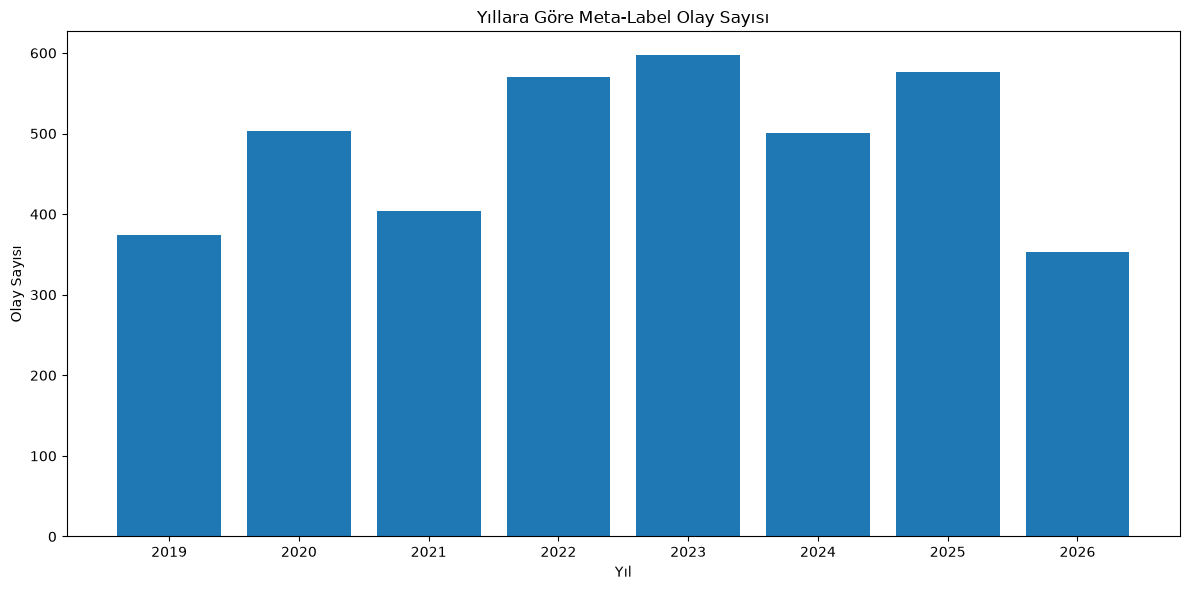

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(
    yearly_summary["Year"].astype(str),
    yearly_summary["Event_Count"],
)
plt.title("Yıllara Göre Meta-Label Olay Sayısı")
plt.xlabel("Yıl")
plt.ylabel("Olay Sayısı")
plt.tight_layout()
plt.show()


## 9. Özellik eksikliği ve temel istatistikler


In [13]:
feature_missingness = (
    training_dataset[BASE_FEATURE_COLUMNS]
    .isna()
    .sum()
    .rename("Missing_Count")
    .reset_index()
    .rename(columns={"index": "Feature"})
)

feature_missingness["Missing_Rate_%"] = (
    feature_missingness["Missing_Count"]
    / len(training_dataset)
    * 100
)

display(
    feature_missingness.sort_values(
        "Missing_Count",
        ascending=False,
    )
)


,Feature,Missing_Count,Missing_Rate_%
0,Score,0,0.0
1,RSI,0,0.0
2,ADX,0,0.0
3,ATR_PCT,0,0.0
4,MACD_HIST_PCT,0,0.0
5,VOLUME_RATIO,0,0.0
6,RET_5,0,0.0
7,RET_20,0,0.0
8,RET_63,0,0.0
9,RET_126,0,0.0


In [14]:
feature_describe = (
    training_dataset[BASE_FEATURE_COLUMNS]
    .describe()
    .T
)

display(feature_describe)


,count,mean,std,min,25%,50%,75%,max
Score,3879.0,11.720804,0.911594,11.000000,11.000000,11.000000,12.000000,14.000000
RSI,3879.0,60.666172,6.883372,46.654908,55.485686,59.930256,64.951320,90.256347
ADX,3879.0,25.434044,11.079189,7.279438,17.792723,22.780765,30.377582,78.104689
ATR_PCT,3879.0,0.040656,0.012895,0.013618,0.031354,0.038059,0.047864,0.104192
MACD_HIST_PCT,3879.0,0.003814,0.007988,-0.026386,-0.000373,0.003344,0.008009,0.061770
VOLUME_RATIO,3879.0,1.863028,0.961839,0.048393,1.371671,1.611639,2.085526,12.168028
RET_5,3879.0,0.066313,0.065764,-0.254635,0.027907,0.058517,0.095917,1.322628
RET_20,3879.0,0.082466,0.138371,-0.359345,0.009336,0.054324,0.120591,1.591464
RET_63,3879.0,0.232179,0.348406,-0.583983,0.020179,0.153714,0.339249,3.025836
RET_126,3879.0,0.459684,0.679989,-0.451820,0.077801,0.270653,0.629768,9.721071


## 10. Dosyaları kaydet

Model notebook'u yalnızca `training_dataset` dosyasını kullanacaktır.
Tam olay tablosu, sansürlü son işlemlerin daha sonra güncellenebilmesi için
ayrıca saklanır.


In [15]:
ML_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml"
)
ML_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ml_dataset.to_parquet(
    ML_RESULTS_DIR
    / "robot_meta_label_events_all.parquet",
    index=False,
)

training_dataset.to_parquet(
    ML_RESULTS_DIR
    / "robot_meta_label_training.parquet",
    index=False,
)

training_dataset.to_csv(
    ML_RESULTS_DIR
    / "robot_meta_label_training.csv",
    index=False,
)

split_summary.to_csv(
    ML_RESULTS_DIR
    / "meta_label_split_summary.csv",
    index=False,
)

outcome_by_score.to_csv(
    ML_RESULTS_DIR
    / "meta_label_outcome_by_score.csv",
    index=False,
)

exit_reason_summary.to_csv(
    ML_RESULTS_DIR
    / "meta_label_exit_reasons.csv",
    index=False,
)

yearly_summary.to_csv(
    ML_RESULTS_DIR
    / "meta_label_yearly_summary.csv",
    index=False,
)

leakage_report.to_csv(
    ML_RESULTS_DIR
    / "meta_label_leakage_audit.csv",
    index=False,
)

save_feature_manifest(
    feature_columns=BASE_FEATURE_COLUMNS,
    path=MODEL_DIR
    / "meta_label_feature_manifest.json",
)

print("ML meta-label dataset dosyaları kaydedildi.")


ML meta-label dataset dosyaları kaydedildi.


## Sonraki aşama

Model seçiminde rastgele train-test split kullanılmayacak.

Plan:

1. Development döneminde zaman sıralı eğitim ve cross-validation
2. Validation döneminde model ve olasılık eşiği seçimi
3. `2025+` döneminde yalnızca raporlama
4. Seçilen ML filtresini final portföy backtestine entegre etme
5. Robot + ML sonucunu hem orijinal Robot hem de BIST100 ile karşılaştırma
